# 10 Full Temporal Application: S2-only over all available scenes (2019–2023)

**Author:** Florian Klaver

This notebook is not a large part of the thesis. It was created during the second-last month of the thesis-work to apply the then best model over all available S2-images. The goal was to provide a full mowing-detection prediction over the full time period to the supervisor, before the parent-project this thesis is embedded in (project of ZHAW research group together with the Zurich Airport) was finished. At the end of the thesis-work the notebook was adjusted to use the new best S2_only model and adjusted postprocessing. But the new results are not analysed in more detaile or discussed in the thesis report.

---

This notebook applies the best S2-only model (S2_only_diff_rf with median and morpholigical postprocessing) to every consecutive TIF pair in `data/Sentinel_CH/` that falls within the mowing season (April – October) and has a gap ≤ 15 days. Cloud-masked and grassland-filtered via `prepare_scene_features` from `src/evaluation.py`.

**Outputs** go to `data/operational_results/full_application/`:
- `mowed_<before>_to_<after>.tif`:  postprocessed prediction raster (−1/0/1)
- `run_summary.csv`: per-pair status, valid pixels, mowed pixels
- `mowed_area_timeseries.png`:  mowed area (ha) bar chart over time

---
## 1. Setup & Imports

In [8]:
import sys
import os
import importlib
import numpy as np
import pandas as pd
import rasterio
import joblib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.abspath('..'))

import src.evaluation
import src.postprocessing
import src.config
importlib.reload(src.evaluation)
importlib.reload(src.postprocessing)
importlib.reload(src.config)

from src.evaluation import FEATURE_NAMES, prepare_scene_features
from src.postprocessing import postprocess_prediction
from src.config import (
    S2_SCENES_DIR, AV_LANDUSE_PATH, AV_FIREBRIGADE_PATH,
    MODELS_DIR, RESULTS_DIR, PP_DISK_RADIUS, PP_MIN_AREA_PX, PP_MEDIAN_SIZE,
)

OUTPUT_DIR = RESULTS_DIR / 'full_application'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Configs for seperate run for 2024
OUTPUT_DIR = Path('../data/2024/full_application')
S2_SCENES_DIR = Path('../data/2024/S2_2024_CH')


print(f'S2 scenes dir:  {S2_SCENES_DIR}')
print(f'Models dir:     {MODELS_DIR}')
print(f'Output dir:     {OUTPUT_DIR}')
print(f'PP disk_radius: {PP_DISK_RADIUS}  min_area_px: {PP_MIN_AREA_PX}  median_size: {PP_MEDIAN_SIZE}')
print('Setup complete.')

S2 scenes dir:  ..\data\2024\S2_2024_CH
Models dir:     C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\models
Output dir:     ..\data\2024\full_application
PP disk_radius: 1  min_area_px: 4  median_size: 3
Setup complete.


---
## 2. Build Scene Pairs

Discover all `YYYY-MM-DD.tif` files, sort by date, and form consecutive pairs.
Pairs are kept only when:
- Both dates fall within the mowing season (`SEASON_START_MONTH`–`SEASON_END_MONTH`)
- The gap between acquisitions is ≤ `MAX_GAP_DAYS` (avoids bridging winter or multi-year data gaps)

In [9]:
# Parameters
MAX_GAP_DAYS = 15   # maximum days between before/after scene
SEASON_START_MONTH = 4    # April (inclusive)
SEASON_END_MONTH = 10   # October (inclusive)


tif_files = sorted(S2_SCENES_DIR.glob('*.tif'))
dates     = [datetime.strptime(f.stem, '%Y-%m-%d').date() for f in tif_files]

pairs = []
for i in range(len(dates) - 1):
    d_before, d_after = dates[i], dates[i + 1]
    gap = (d_after - d_before).days
    in_season = (SEASON_START_MONTH <= d_before.month <= SEASON_END_MONTH and
                 SEASON_START_MONTH <= d_after.month  <= SEASON_END_MONTH)
    if in_season and gap <= MAX_GAP_DAYS:
        pairs.append({
            'before_date': d_before,
            'after_date':  d_after,
            'before_path': str(tif_files[i]),
            'after_path':  str(tif_files[i + 1]),
            'gap_days':    gap,
        })

pairs_df = pd.DataFrame(pairs)

print(f'Total TIF files:   {len(tif_files)}  ({dates[0]} → {dates[-1]})')
print(f'Candidate pairs:   {len(pairs_df)}  '
      f'(season {SEASON_START_MONTH}–{SEASON_END_MONTH}, gap ≤ {MAX_GAP_DAYS} days)')
print()
print(pairs_df[['before_date', 'after_date', 'gap_days']].to_string(index=False))

Total TIF files:   144  (2024-01-01 → 2024-12-29)
Candidate pairs:   84  (season 4–10, gap ≤ 15 days)

before_date after_date  gap_days
 2024-04-03 2024-04-05         2
 2024-04-05 2024-04-08         3
 2024-04-08 2024-04-10         2
 2024-04-10 2024-04-13         3
 2024-04-13 2024-04-15         2
 2024-04-15 2024-04-18         3
 2024-04-18 2024-04-20         2
 2024-04-20 2024-04-23         3
 2024-04-23 2024-04-25         2
 2024-04-25 2024-04-28         3
 2024-04-28 2024-04-30         2
 2024-04-30 2024-05-03         3
 2024-05-03 2024-05-05         2
 2024-05-05 2024-05-08         3
 2024-05-08 2024-05-10         2
 2024-05-10 2024-05-13         3
 2024-05-13 2024-05-15         2
 2024-05-15 2024-05-18         3
 2024-05-18 2024-05-20         2
 2024-05-20 2024-05-23         3
 2024-05-23 2024-05-25         2
 2024-05-25 2024-05-28         3
 2024-05-28 2024-05-30         2
 2024-05-30 2024-06-02         3
 2024-06-02 2024-06-04         2
 2024-06-04 2024-06-07         3
 2024-

---
## 3. Load Model

Loads `s2_only_diff_rf.joblib` from the models directory.


In [10]:
artifact = joblib.load(MODELS_DIR / 's2_only_diff_rf.joblib')
model   = artifact['model']
feat_s2 = artifact['features']

MODEL_THRESHOLD = artifact['threshold']

print(f'Model type:  {type(model).__name__}')
print(f'Features:    {feat_s2}')
print(f'Threshold:   {MODEL_THRESHOLD:.4f}  (calibrated, loaded from artifact)')

Model type:  Pipeline
Features:    ['ndii_diff', 'gndvi_diff', 'swir_diff']
Threshold:   0.8750  (calibrated, loaded from artifact)


---
## 4. Processing Loop

For each pair:
1. `prepare_scene_features` — grassland mask + airport mask + cloud mask + all vegetation indices
2. Skip if fewer than `MIN_VALID_FRACTION` of pixels survive masking (very cloudy scene)
3. Run RF model in-memory with calibrated threshold → int8 map `{-1, 0, 1}`
4. `postprocess_prediction` — median filter + morphological open/close + minimum area filter
5. Write postprocessed GeoTIFF (uint8, nodata=255) and record stats in summary

In [11]:
MIN_VALID_FRACTION = 0.05  # skip pair if < 5% of pixels are valid after cloud masking

summary_rows = []

for idx, row in pairs_df.iterrows():
    before_str = str(row['before_date'])
    after_str  = str(row['after_date'])
    label      = f'{before_str}_to_{after_str}'
    out_pp     = OUTPUT_DIR / f'mowed_{label}.tif'

    # Prepare features
    try:
        fdf, vmask, meta, H, W = prepare_scene_features(
            row['before_path'], row['after_path'],
            str(AV_LANDUSE_PATH), str(AV_FIREBRIGADE_PATH),
            FEATURE_NAMES)
    except Exception as e:
        print(f'  ERROR {label}: {e}')
        summary_rows.append({**row, 'status': 'error', 'n_valid': 0, 'n_mowed': 0})
        continue

    valid_fraction = vmask.sum() / (H * W)
    if valid_fraction < MIN_VALID_FRACTION:
        print(f'  SKIP  {label}  valid={valid_fraction:.1%}  (too cloudy)')
        summary_rows.append({**row, 'status': 'skipped_cloud',
                              'n_valid': int(vmask.sum()), 'n_mowed': 0})
        continue

    # Predict (in-memory)
    avail_feats = [f for f in feat_s2 if f in fdf.columns]
    pred_flat = np.full(H * W, -1, dtype=np.int8)
    if vmask.sum() > 0:
        proba = model.predict_proba(fdf.loc[vmask, avail_feats])[:, 1]
        pred_flat[vmask] = (proba >= MODEL_THRESHOLD).astype(np.int8)
    pred_map = pred_flat.reshape(H, W)

    # Postprocess
    pred_pp = postprocess_prediction(pred_map, method='median+morphological',
                                     median_size=PP_MEDIAN_SIZE,
                                     disk_radius=PP_DISK_RADIUS,
                                     min_area_pixels=PP_MIN_AREA_PX)

    # Save (uint8, nodata=255, matching prototype encoding)
    out_arr = pred_pp.astype(np.uint8)   # -1 wraps to 255 (nodata)
    pp_meta = meta.copy()
    pp_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255})
    with rasterio.open(str(out_pp), 'w', **pp_meta) as dst:
        dst.write(out_arr, 1)

    n_valid = int(vmask.sum())
    n_mowed = int((pred_pp[pred_pp >= 0] == 1).sum())
    pct     = 100 * n_mowed / max(n_valid, 1)
    print(f'  OK    {label}  '
          f'valid={n_valid:,}  mowed={n_mowed:,}  ({pct:.1f}%)')
    summary_rows.append({**row, 'status': 'ok',
                          'n_valid': n_valid, 'n_mowed': n_mowed})

# Save summary
summary_df = pd.DataFrame(summary_rows)
csv_path   = OUTPUT_DIR / 'run_summary.csv'
summary_df.to_csv(csv_path, index=False)

print(f'\n{"="*60}')
print(f'Done.  Processed: {(summary_df.status=="ok").sum()} / {len(summary_df)} pairs')
print(f'Skipped (cloud):  {(summary_df.status=="skipped_cloud").sum()}')
print(f'Errors:           {(summary_df.status=="error").sum()}')
print(f'Summary saved →   {csv_path}')
print()
print(summary_df[['before_date', 'after_date', 'gap_days',
                   'status', 'n_valid', 'n_mowed']].to_string(index=False))

Before: 2024-04-03.tif
After:  2024-04-05.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  SKIP  2024-04-03_to_2024-04-05  valid=0.0%  (too cloudy)
Before: 2024-04-05.tif
After:  2024-04-08.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  SKIP  2024-04-05_to_2024-04-08  valid=0.0%  (too cloudy)
Before: 2024-04-08.tif
After:  2024-04-10.tif


...

  SKIP  2024-10-22_to_2024-10-25  valid=0.0%  (too cloudy)
Before: 2024-10-25.tif
After:  2024-10-27.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  SKIP  2024-10-25_to_2024-10-27  valid=0.0%  (too cloudy)
Before: 2024-10-27.tif
After:  2024-10-30.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  SKIP  2024-10-27_to_2024-10-30  valid=0.0%  (too cloudy)

Done.  Processed: 4 / 84 pairs
Skipped (cloud):  80
Errors:           0
Summary saved →   ..\data\2024\full_application\run_summary.csv

before_date after_date  gap_days        status  n_valid  n_mowed
 2024-04-03 2024-04-05         2 skipped_cloud       11        0
 2024-04-05 2024-04-08         3 skipped_cloud        0        0
 2024-04-08 2024-04-10         2 skipped_cloud        0        0
 2024-04-10 2024-04-13         3 skipped_cloud        4        0
 2024-04-13 2024-04-15         2 skipped_cloud        0        0
 2024-04-15 2024-04-18         3 skipped_cloud        0        0
 2024-04-18 2024-04-20         2 skipped_cloud       19        0
 2024-04-20 2024-04-23         3 skipped_cloud        0        0
 2024-04-23 2024-04-25         2 skipped_cloud        0        0
 2024-04-25 2024-04-28         3 skipped_cloud        0        0
 2024-04-28 2024-04-30         2 skipped_cloud        0        0
 2024-04-30 2024-05-03 

---
## 5. Summary Visualisation

Bar chart of detected mowed area (ha) per pair over time, coloured by year.

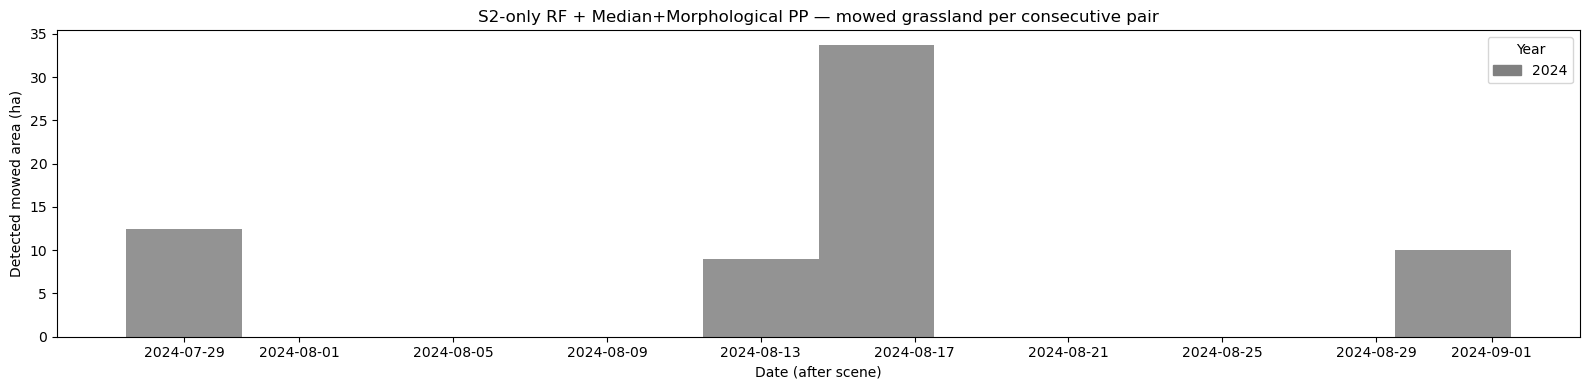

Saved: ..\data\2024\full_application\mowed_area_timeseries.png

=== Mowed area statistics per year ===
      n_pairs  mean_ha  max_ha  total_ha
year                                    
2024        4     16.3    33.7      65.2


In [12]:
ok = summary_df[summary_df['status'] == 'ok'].copy()
ok['after_dt'] = pd.to_datetime(ok['after_date'])
ok['mowed_ha'] = ok['n_mowed'] * (10 * 10) / 10_000   # 10 m pixels → ha

year_colors = {2019: '#1f77b4', 2020: '#ff7f0e',
               2021: '#2ca02c', 2022: '#d62728', 2023: '#9467bd'}

fig, ax = plt.subplots(figsize=(16, 4))

for _, r in ok.iterrows():
    year  = r['after_dt'].year
    color = year_colors.get(year, 'grey')
    ax.bar(r['after_dt'], r['mowed_ha'], width=3, color=color, alpha=0.85)

ax.set_xlabel('Date (after scene)')
ax.set_ylabel('Detected mowed area (ha)')
ax.set_title('S2-only RF + Median+Morphological PP — mowed grassland per consecutive pair')

from matplotlib.patches import Patch
present_years = sorted(ok['after_dt'].dt.year.unique())
ax.legend(handles=[Patch(color=year_colors.get(y, 'grey'), label=str(y))
                   for y in present_years], title='Year')

plt.tight_layout()
out_png = OUTPUT_DIR / 'mowed_area_timeseries.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

# --- Quick stats per year ---
print('\n=== Mowed area statistics per year ===')
ok['year'] = ok['after_dt'].dt.year
print(ok.groupby('year')['mowed_ha'].agg(['count', 'mean', 'max', 'sum']).round(1).rename(
    columns={'count': 'n_pairs', 'mean': 'mean_ha', 'max': 'max_ha', 'sum': 'total_ha'}).to_string())

---
## 6. Visualise a Single Result

Visualising: 2024-08-28_to_2024-08-31  (mowed=1,006 px)


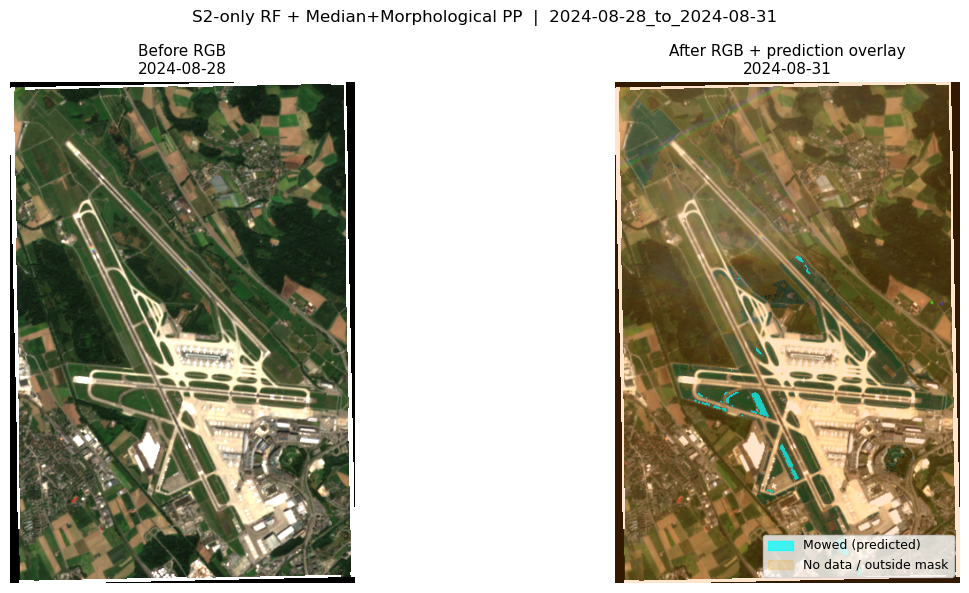

In [21]:
# Choose which pair to inspect
# Set to any after_date string from run_summary.csv, e.g. '2019-05-15'
VIZ_AFTER_DATE = '2024-08-31'   


if VIZ_AFTER_DATE is None:
    row_viz = ok.loc[ok['n_mowed'].idxmax()]
else:
    row_viz = ok[ok['after_date'].astype(str) == VIZ_AFTER_DATE].iloc[0]

before_str = str(row_viz['before_date'])
after_str  = str(row_viz['after_date'])
label      = f'{before_str}_to_{after_str}'
pred_path  = OUTPUT_DIR / f'mowed_{label}.tif'

print(f'Visualising: {label}  (mowed={int(row_viz["n_mowed"]):,} px)')

# Load prediction (uint8: 1=mowed, 0=not mowed, 255=nodata)
with rasterio.open(pred_path) as src:
    pred = src.read(1).astype(float)

def _load_rgb(path):
    with rasterio.open(path) as src:
        r = np.clip(src.read(3).astype(float) / 2500, 0, 1)
        g = np.clip(src.read(2).astype(float) / 2500, 0, 1)
        b = np.clip(src.read(1).astype(float) / 2500, 0, 1)
    return np.dstack([r, g, b])

rgb_before = _load_rgb(row_viz['before_path'])
rgb_after  = _load_rgb(row_viz['after_path'])

# Prediction overlay: mowed=cyan, nodata=semi-dark
overlay = np.zeros((*pred.shape, 4), dtype=float)
overlay[pred == 1]   = [0, 1, 1, 0.7]    # mowed
overlay[pred == 255] = [1, 0.5, 0, 0.20]   # nodata

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb_before)
axes[0].set_title(f'Before RGB\n{before_str}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(rgb_after)
axes[1].imshow(overlay)
axes[1].set_title(f'After RGB + prediction overlay\n{after_str}', fontsize=11)
axes[1].axis('off')

axes[1].legend(handles=[Patch(color='cyan',  alpha=0.7,  label='Mowed (predicted)'),
                         Patch(color='orange', alpha=0.20, label='No data / outside mask')],
               loc='lower right', fontsize=9)

plt.suptitle(f'S2-only RF + Median+Morphological PP  |  {label}', fontsize=12)
plt.tight_layout()
plt.show()